In [ ]:
# Data manipulation library
import numpy as np 
import pandas as pd 
# import data visulization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier
# import logging libraries
import logging
logging.basicConfig(level = logging.INFO,
                    filename= 'model.log',
                    filemode= 'w',
                    format= '%(asctime)s - %(message)s - %(levelname)s',
                    force = True)
# Import filter warning libraries
import warnings
warnings.filterwarnings(action= 'ignore')

# steps to be followed

'''
step1:- Data Ingestion : Loading data using pandas function 
step2:- Understand Dataset : Categorical and Numerical column information
step3:- Descriptive Stats for Categorical and Numerical Columns
step4:- Build stratergies based on type and nature of dataset and accordingly do preprocessing
'''

In [ ]:
# step1:- data Ingestion

df = pd.read_csv(r'C:\telecom_churnmodel\data\churn.csv')

df.sample(frac = 1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1193,5232-NXPAY,Female,0,No,No,47,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,74.45,3510.3,No
4155,6904-JLBGY,Female,1,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),117.35,8436.25,No
4928,2718-GAXQD,Female,1,Yes,Yes,4,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,46.00,181.6,Yes
6008,4451-RWASJ,Male,0,Yes,Yes,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.50,239.75,No
5587,1707-HABPF,Female,1,No,No,46,Yes,No,Fiber optic,No,...,Yes,No,Yes,No,One year,Yes,Bank transfer (automatic),91.30,4126.35,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2546,7175-NTIXE,Female,0,No,No,25,Yes,No,DSL,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),76.15,1992.95,No
5615,1493-AMTIE,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.2,Yes
4277,5955-EPOAZ,Female,0,No,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.95,109.5,No
2949,3489-VSFRD,Female,0,No,No,56,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Credit card (automatic),60.25,3282.75,No


In [9]:
# step2:- Checking dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

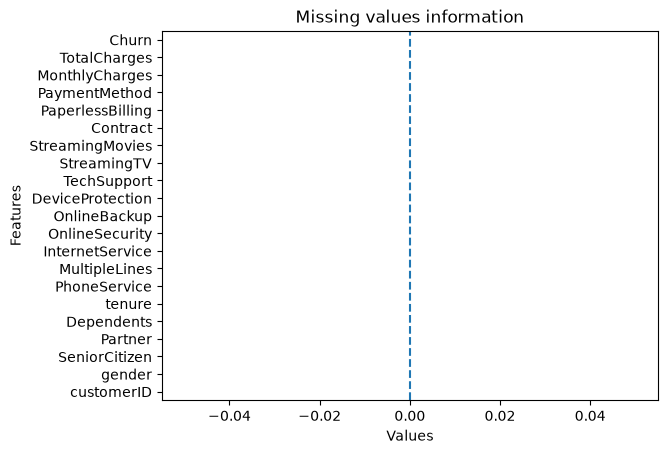

In [ ]:
# Checking the missing values 
df.isnull().sum().plot(kind = 'barh')
plt.axvline(0,linestyle = '--')
plt.title('Missing values information')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

In [ ]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

In [11]:
numerical_data = df.select_dtypes(exclude = 'object')
categorical_data = df.select_dtypes(include= 'object')